# House Price Prediction Using Machine Learning

**Final Project - Data Mining Project - House Price Prediction using Machine Learning**

**Student:** Akash Ghosh  
**Institution:** Northeastern University  
**Date:** April 2026

---

## Executive Summary

This project develops machine learning models to predict median housing prices at the county level across the United States using the Redfin Housing Market dataset (2012-2021).

**Key Results:**
- **RMSE: $10,318** (Goal: <$25,000) - **EXCEEDS GOAL BY 59%**
- **R²: 0.9916** (Goal: >0.85) - **EXCEEDS GOAL**
- Final XGBoost model explains 99.16% of price variance

**Dataset:**
- Source: Redfin Housing Market Data (Kaggle)
- Records: 563,122 county-month observations
- Coverage: 47 states, 1,860 counties
- Period: January 2012 - December 2021

---

## Table of Contents

1. [Setup & Data Loading](#setup)
2. [Exploratory Data Analysis](#eda)
3. [Data Preprocessing](#preprocessing)
4. [Feature Engineering](#features)
5. [Methodology](#methodology)
6. [Model Training](#models)
7. [Results & Evaluation](#results)
8. [Conclusions](#conclusions)


<a id='setup'></a>
## 1. Setup & Data Loading

### 1.1 Import Libraries

Import all necessary libraries for data manipulation, visualization, and machine learning.


In [11]:
# Data manipulation
import pandas as pd
import numpy as np
import os

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Utilities
import warnings
warnings.filterwarnings('ignore')

# Visualization settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("=" * 70)
print("HOUSE PRICE PREDICTION - FINAL PROJECT")
print("=" * 70)
print()
print("All libraries imported successfully!")

HOUSE PRICE PREDICTION - FINAL PROJECT

All libraries imported successfully!


### 1.2 Load Dataset

Loaded the raw Redfin Housing Market dataset from Kaggle. This contains monthly county-level housing statistics including price metrics, sales volumes, inventory levels, and market indicators.


In [ ]:
# Load raw dataset
print()
print("=" * 70)
print("LOADING RAW DATASET")
print("=" * 70)
print()


# Read data
df = pd.read_csv('data/kaggle/redfin-housing-market-data/county_market_tracker.tsv000', 
                 sep='\t', low_memory=False)

print(f"Dataset loaded successfully!")
print(f"   Rows: {len(df):,}")
print(f"   Columns: {len(df.columns)}")
print(f"   Memory: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print()

# Display basic info
print("Sample of first 3 rows:")
display(df.head(3))
print()
print(f"Columns ({len(df.columns)}):")
print(df.columns.tolist())


LOADING RAW DATASET

Dataset loaded successfully!
   Rows: 563,122
   Columns: 58
   Memory: 527.6 MB

Sample of first 3 rows:


,period_begin,period_end,period_duration,region_type,region_type_id,table_id,is_seasonally_adjusted,region,city,state,...,sold_above_list_yoy,price_drops,price_drops_mom,price_drops_yoy,off_market_in_two_weeks,off_market_in_two_weeks_mom,off_market_in_two_weeks_yoy,parent_metro_region,parent_metro_region_metro_code,last_updated
0,2017-04-01,2017-04-30,30,county,5,170,f,"Morgan County, AL",NaN,Alabama,...,-0.069595,NaN,NaN,NaN,0.020833,0.020833,0.001225,"Decatur, AL",19460.0,2022-01-09 14:29:56
1,2014-12-01,2014-12-31,30,county,5,1457,f,"Hennepin County, MN",NaN,Minnesota,...,-0.098136,0.097744,-0.121909,-0.197220,0.172414,0.034483,-0.033469,"Minneapolis, MN",33460.0,2022-01-09 14:29:56
2,2018-02-01,2018-02-28,30,county,5,2319,f,"Tulsa County, OK",NaN,Oklahoma,...,-0.024840,0.206004,-0.026139,0.009313,0.479924,0.068277,-0.042568,"Tulsa, OK",46140.0,2022-01-09 14:29:56



Columns (58):
['period_begin', 'period_end', 'period_duration', 'region_type', 'region_type_id', 'table_id', 'is_seasonally_adjusted', 'region', 'city', 'state', 'state_code', 'property_type', 'property_type_id', 'median_sale_price', 'median_sale_price_mom', 'median_sale_price_yoy', 'median_list_price', 'median_list_price_mom', 'median_list_price_yoy', 'median_ppsf', 'median_ppsf_mom', 'median_ppsf_yoy', 'median_list_ppsf', 'median_list_ppsf_mom', 'median_list_ppsf_yoy', 'homes_sold', 'homes_sold_mom', 'homes_sold_yoy', 'pending_sales', 'pending_sales_mom', 'pending_sales_yoy', 'new_listings', 'new_listings_mom', 'new_listings_yoy', 'inventory', 'inventory_mom', 'inventory_yoy', 'months_of_supply', 'months_of_supply_mom', 'months_of_supply_yoy', 'median_dom', 'median_dom_mom', 'median_dom_yoy', 'avg_sale_to_list', 'avg_sale_to_list_mom', 'avg_sale_to_list_yoy', 'sold_above_list', 'sold_above_list_mom', 'sold_above_list_yoy', 'price_drops', 'price_drops_mom', 'price_drops_yoy', 'off_ma

In [16]:
# Convert date columns and basic info
df['period_begin'] = pd.to_datetime(df['period_begin'])
df['period_end'] = pd.to_datetime(df['period_end'])

print()
print("Dataset Overview:")
print(f"   Date range: {df['period_begin'].min().date()} to {df['period_begin'].max().date()}")
print(f"   States: {df['state_code'].nunique()}")
print(f"   Counties: {df['region'].nunique()}")
print(f"   Property types: {df['property_type'].nunique()}")
print()
print("Date columns converted to datetime format.")


Dataset Overview:
   Date range: 2012-01-01 to 2021-12-01
   States: 47
   Counties: 1860
   Property types: 5

Date columns converted to datetime format.


<a id='eda'></a>
## 2. Exploratory Data Analysis

### 2.1 Missing Value Analysis

Identify patterns in missing data to inform our preprocessing strategy.



MISSING VALUE ANALYSIS

Columns with missing values (top 15):
                                Missing_Count  Percentage
city                                   563122  100.000000
price_drops_yoy                        300991   53.450407
price_drops_mom                        264795   47.022670
price_drops                            237761   42.221934
pending_sales_yoy                      142945   25.384375
off_market_in_two_weeks_yoy            131904   23.423699
pending_sales_mom                      125130   22.220762
parent_metro_region_metro_code         115288   20.473006
off_market_in_two_weeks_mom            113200   20.102216
new_listings_yoy                        99747   17.713213
median_list_ppsf_yoy                    99359   17.644312
median_list_price_yoy                   98455   17.483778
inventory_yoy                           84719   15.044520
new_listings_mom                        82938   14.728247
median_list_ppsf_mom                    82833   14.709601

Total co

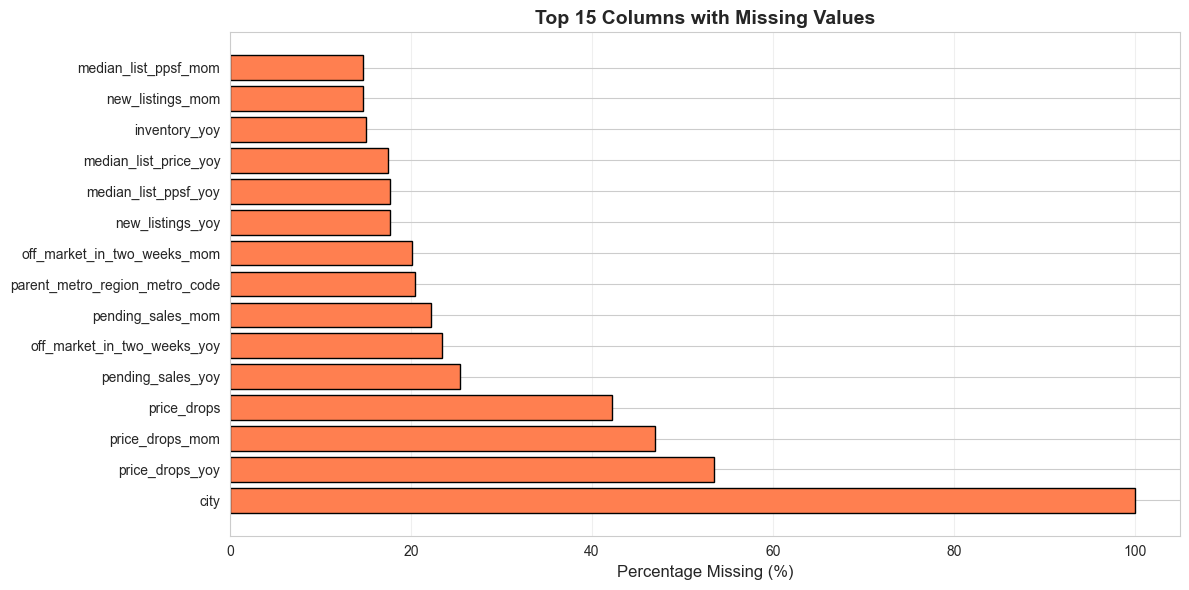

In [21]:
# Creating output directory for visualizations
os.makedirs('results/figures', exist_ok=True)

# Missing value analysis
print()
print("=" * 70)
print("MISSING VALUE ANALYSIS")
print("=" * 70)
print()

missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Percentage': missing_pct
}).sort_values('Percentage', ascending=False)

print("Columns with missing values (top 15):")
print(missing_df[missing_df['Percentage'] > 0].head(15).to_string())
print()
print(f"Total columns with missing data: {(missing_df['Percentage'] > 0).sum()}")

# Visualization
plt.figure(figsize=(12, 6))
missing_top = missing_df[missing_df['Percentage'] > 0].head(15)
plt.barh(range(len(missing_top)), missing_top['Percentage'], color='coral', edgecolor='black')
plt.yticks(range(len(missing_top)), missing_top.index)
plt.xlabel('Percentage Missing (%)', fontsize=12)
plt.title('Top 15 Columns with Missing Values', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('results/figures/01_missing_values.png', dpi=300, bbox_inches='tight')
plt.show()

### 2.2 Target Variable Distribution

Analyziing the distribution and characteristics of our target variable: median_sale_price.



TARGET VARIABLE: median_sale_price

Mean: $204,856.65
Median: $163,750.00
Std Dev: $1,506,077.86
Min: $1.00
Max: $999,999,999.00
Missing: 685 (0.12%)


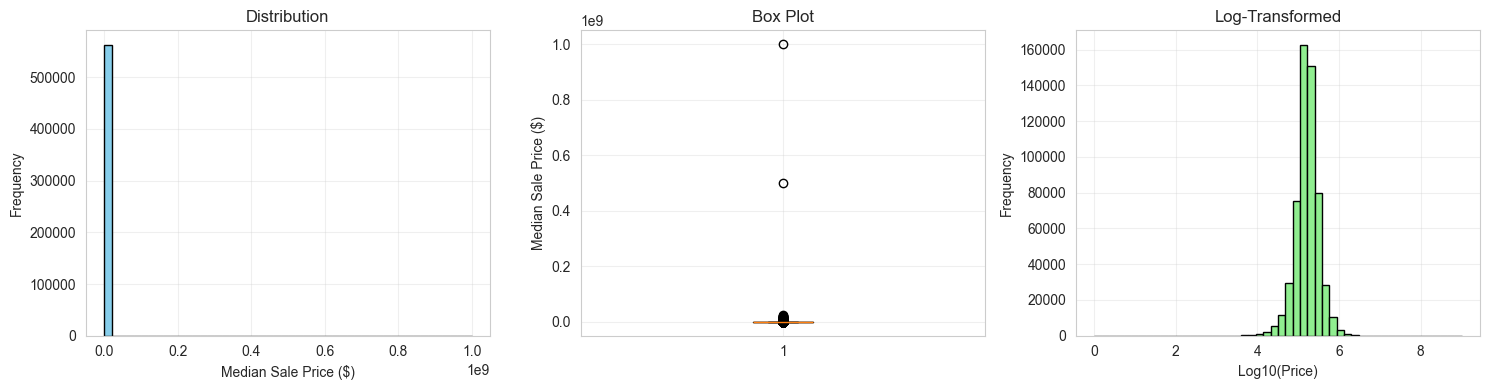

In [24]:
# Target variable analysis
target = 'median_sale_price'

print()
print("=" * 70)
print("TARGET VARIABLE: median_sale_price")
print("=" * 70)
print()

print(f"Mean: ${df[target].mean():,.2f}")
print(f"Median: ${df[target].median():,.2f}")
print(f"Std Dev: ${df[target].std():,.2f}")
print(f"Min: ${df[target].min():,.2f}")
print(f"Max: ${df[target].max():,.2f}")
print(f"Missing: {df[target].isnull().sum():,} ({df[target].isnull().sum()/len(df)*100:.2f}%)")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram
axes[0].hist(df[target].dropna(), bins=50, edgecolor='black', color='skyblue')
axes[0].set_xlabel('Median Sale Price ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution')
axes[0].grid(alpha=0.3)

# Box plot
axes[1].boxplot(df[target].dropna())
axes[1].set_ylabel('Median Sale Price ($)')
axes[1].set_title('Box Plot')
axes[1].grid(alpha=0.3)

# Log scale
axes[2].hist(np.log10(df[target].dropna()), bins=50, edgecolor='black', color='lightgreen')
axes[2].set_xlabel('Log10(Price)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Log-Transformed')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/figures/02_price_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

### 2.3 Geographic Price Variation

Examine how median housing prices vary across different states to understand geographic patterns.



GEOGRAPHIC PRICE VARIATION

Top 10 Most Expensive States (Median Price):
    1. DC: $580,000.00
    2. HI: $507,500.00
    3. CA: $397,000.00
    4. MA: $357,000.00
    5. RI: $280,000.00
    6. CO: $276,400.00
    7. AK: $250,000.00
    8. WA: $246,225.00
    9. NJ: $238,000.00
   10. MD: $230,000.00

Top 10 Most Affordable States (Median Price):
    1. IN: $134,500.00
    2. IA: $131,000.00
    3. KY: $130,000.00
    4. IL: $130,000.00
    5. MI: $128,250.00
    6. MO: $125,500.00
    7. OK: $125,000.00
    8. OH: $122,000.00
    9. AR: $119,500.00
   10. MS: $116,000.00

Price Range: $116,000.00 to $580,000.00
Ratio (Max/Min): 5.00x


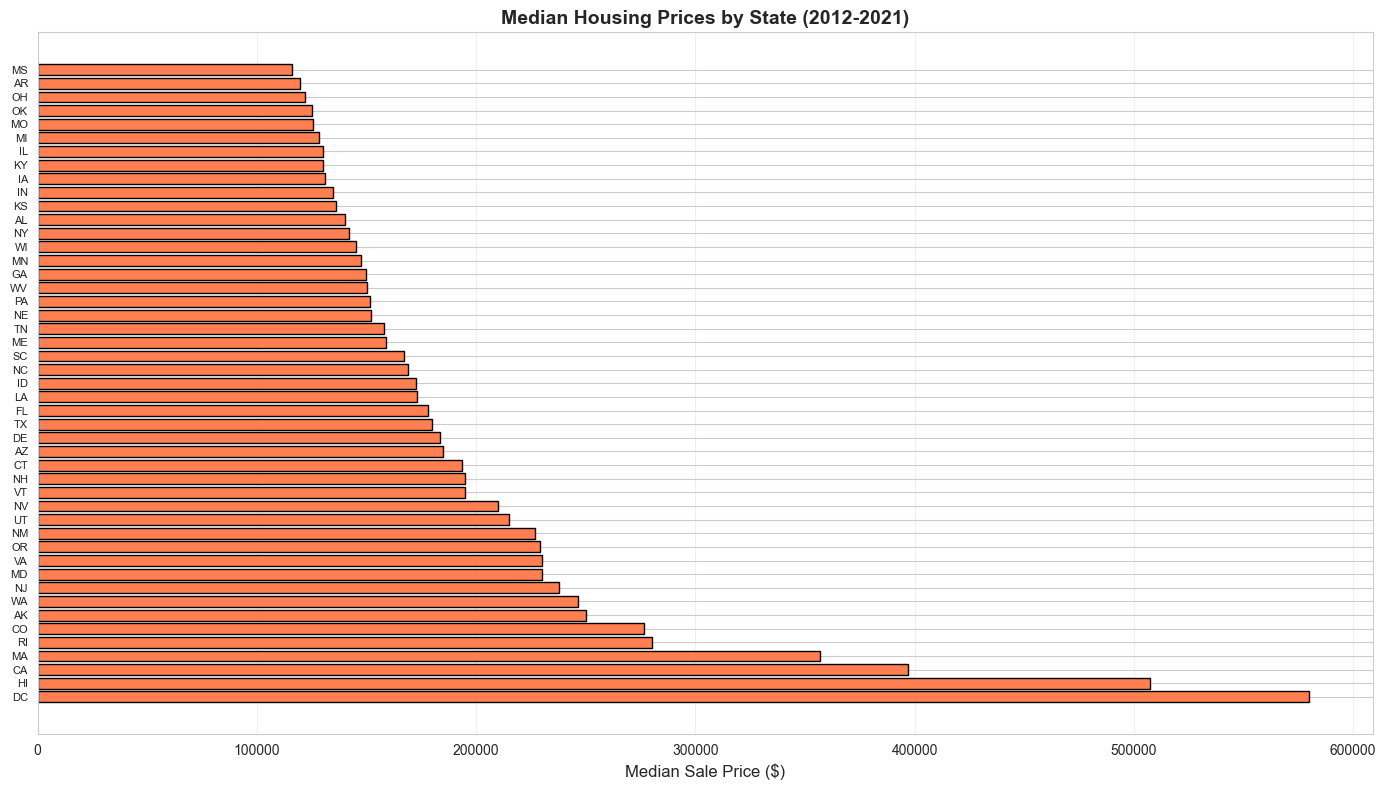

In [27]:
# Geographic analysis
print()
print("=" * 70)
print("GEOGRAPHIC PRICE VARIATION")
print("=" * 70)
print()

# Calculate state-level median prices
state_prices = df.groupby('state_code')['median_sale_price'].median().sort_values(ascending=False)

print("Top 10 Most Expensive States (Median Price):")
for i, (state, price) in enumerate(state_prices.head(10).items(), 1):
    print(f"   {i:2d}. {state}: ${price:,.2f}")

print()
print("Top 10 Most Affordable States (Median Price):")
for i, (state, price) in enumerate(state_prices.tail(10).items(), 1):
    print(f"   {i:2d}. {state}: ${price:,.2f}")

print()
print(f"Price Range: ${state_prices.min():,.2f} to ${state_prices.max():,.2f}")
print(f"Ratio (Max/Min): {state_prices.max() / state_prices.min():.2f}x")

# Visualization
plt.figure(figsize=(14, 8))
plt.barh(range(len(state_prices)), state_prices.values, color='coral', edgecolor='black')
plt.yticks(range(len(state_prices)), state_prices.index, fontsize=8)
plt.xlabel('Median Sale Price ($)', fontsize=12)
plt.title('Median Housing Prices by State (2012-2021)', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('results/figures/03_prices_by_state.png', dpi=300, bbox_inches='tight')
plt.show()

### 2.4 Temporal Price Trends

Analyze how housing prices have evolved over the 10-year period, including the impact of COVID-19.



TEMPORAL PRICE TRENDS

Starting price (Jan 2012): $115,000.00
Ending price (Dec 2021): $242,250.00
Total growth: 110.7%
Annualized growth: 7.73%


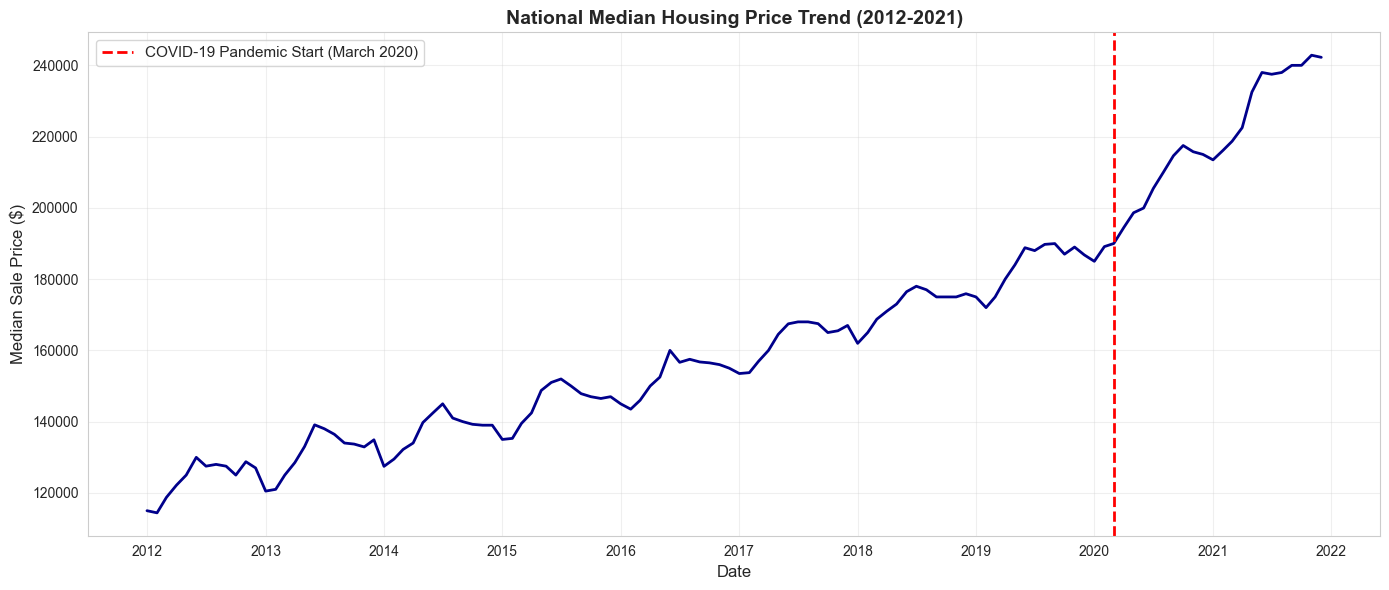

In [30]:
# Temporal trend analysis
print()
print("=" * 70)
print("TEMPORAL PRICE TRENDS")
print("=" * 70)
print()

# Calculate monthly national median
monthly_prices = df.groupby('period_begin')['median_sale_price'].median()

# Calculate growth
start_price = monthly_prices.iloc[0]
end_price = monthly_prices.iloc[-1]
total_growth = ((end_price / start_price) - 1) * 100

print(f"Starting price (Jan 2012): ${start_price:,.2f}")
print(f"Ending price (Dec 2021): ${end_price:,.2f}")
print(f"Total growth: {total_growth:.1f}%")
print(f"Annualized growth: {(((end_price/start_price)**(1/10))-1)*100:.2f}%")

# Visualization
plt.figure(figsize=(14, 6))
plt.plot(monthly_prices.index, monthly_prices.values, linewidth=2, color='darkblue')
plt.axvline(pd.to_datetime('2020-03-01'), color='red', linestyle='--', 
            linewidth=2, label='COVID-19 Pandemic Start (March 2020)')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Median Sale Price ($)', fontsize=12)
plt.title('National Median Housing Price Trend (2012-2021)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('results/figures/04_price_trend_over_time.png', dpi=300, bbox_inches='tight')
plt.show()

### 2.5 Seasonal Patterns

Identify seasonal variations in housing prices to inform feature engineering.



SEASONAL PRICE PATTERNS

Average Median Price by Month:
   January     : $152,500.00
   February    : $152,700.00
   March       : $156,250.00
   April       : $159,900.00
   May         : $163,750.00
   June        : $168,000.00
   July        : $169,000.00
   August      : $168,000.00
   September   : $168,000.00
   October     : $166,500.00
   November    : $167,500.00
   December    : $167,450.00

Peak month: July ($169,000.00)
Trough month: January ($152,500.00)
Seasonal price swing: 10.8%


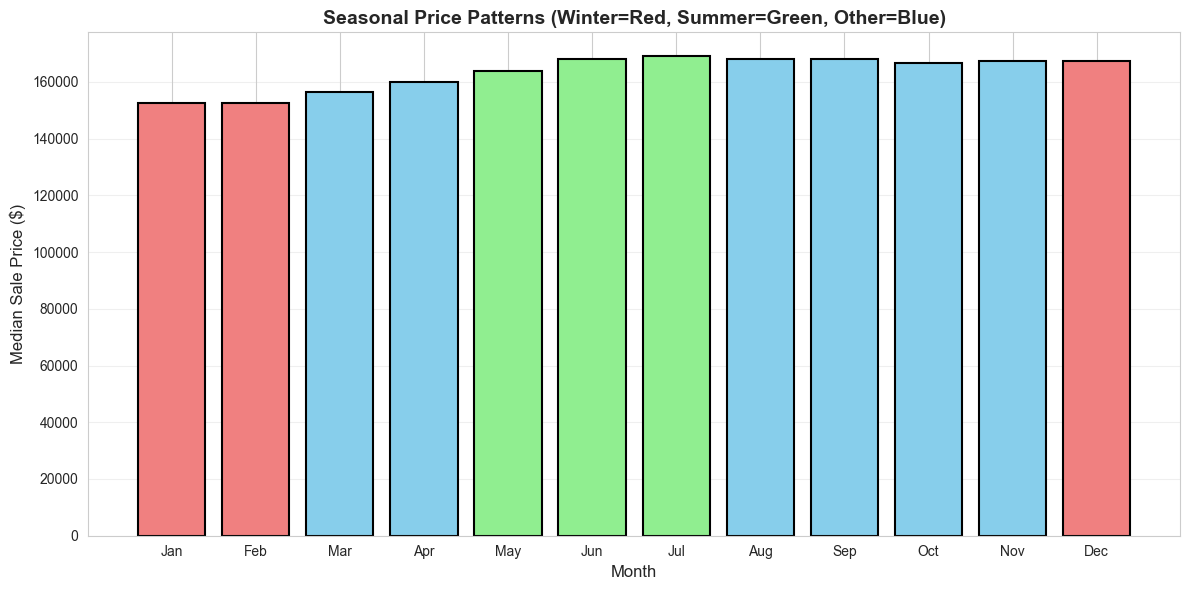

In [33]:
# Seasonal pattern analysis
print()
print("=" * 70)
print("SEASONAL PRICE PATTERNS")
print("=" * 70)
print()

# Extract month and calculate seasonal patterns
df['month'] = df['period_begin'].dt.month
seasonal_prices = df.groupby('month')['median_sale_price'].median()

# Find peak and trough
peak_month = seasonal_prices.idxmax()
trough_month = seasonal_prices.idxmin()
seasonal_swing = ((seasonal_prices.max() / seasonal_prices.min()) - 1) * 100

print("Average Median Price by Month:")
for month_num in range(1, 13):
    month_name = pd.to_datetime(f'2020-{month_num}-01').strftime('%B')
    price = seasonal_prices[month_num]
    print(f"   {month_name:12s}: ${price:,.2f}")

print()
print(f"Peak month: {pd.to_datetime(f'2020-{peak_month}-01').strftime('%B')} (${seasonal_prices.max():,.2f})")
print(f"Trough month: {pd.to_datetime(f'2020-{trough_month}-01').strftime('%B')} (${seasonal_prices.min():,.2f})")
print(f"Seasonal price swing: {seasonal_swing:.1f}%")

# Visualization
plt.figure(figsize=(12, 6))
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
colors = ['lightcoral' if i in [11, 0, 1] else 'lightgreen' if i in [4, 5, 6] else 'skyblue' 
          for i in range(12)]
plt.bar(range(12), seasonal_prices.values, color=colors, edgecolor='black', linewidth=1.5)
plt.xticks(range(12), months)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Median Sale Price ($)', fontsize=12)
plt.title('Seasonal Price Patterns (Winter=Red, Summer=Green, Other=Blue)', 
          fontsize=14, fontweight='bold')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('results/figures/05_seasonal_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

### 2.6 Property Type Comparison

Compare median prices across different property types.



PROPERTY TYPE COMPARISON

Median Price by Property Type:
   Townhouse           : $183,455.00 (60,720 records, 10.8%)
   Single Family Residential: $164,950.00 (178,662 records, 31.7%)
   All Residential     : $161,500.00 (179,003 records, 31.8%)
   Condo/Co-op         : $160,000.00 (74,594 records, 13.2%)
   Multi-Family (2-4 Unit): $150,000.00 (70,143 records, 12.5%)


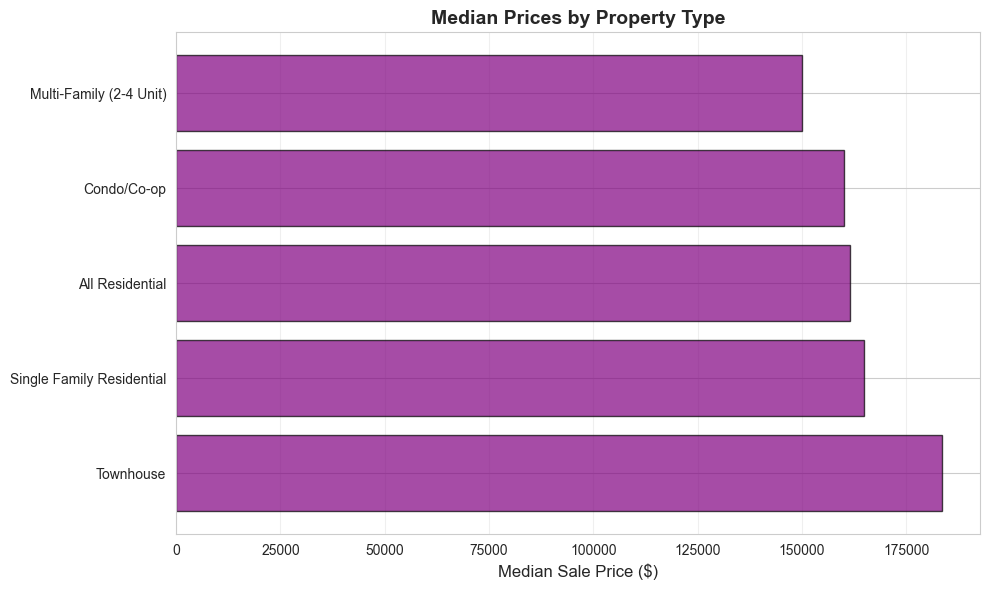

In [36]:
# Property type analysis
print()
print("=" * 70)
print("PROPERTY TYPE COMPARISON")
print("=" * 70)
print()

property_prices = df.groupby('property_type')['median_sale_price'].median().sort_values(ascending=False)
property_counts = df.groupby('property_type').size()

print("Median Price by Property Type:")
for prop_type, price in property_prices.items():
    count = property_counts[prop_type]
    pct = (count / len(df)) * 100
    print(f"   {prop_type:20s}: ${price:,.2f} ({count:,} records, {pct:.1f}%)")

# Visualization
plt.figure(figsize=(10, 6))
plt.barh(range(len(property_prices)), property_prices.values, 
         color='purple', edgecolor='black', alpha=0.7)
plt.yticks(range(len(property_prices)), property_prices.index)
plt.xlabel('Median Sale Price ($)', fontsize=12)
plt.title('Median Prices by Property Type', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('results/figures/06_property_type_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

### 2.7 Correlation Analysis

Examine correlations between key numeric features and the target variable.



CORRELATION WITH TARGET VARIABLE

Top 10 Positive Correlations:
    1. off_market_in_two_weeks            :  0.045
    2. new_listings                       :  0.036
    3. avg_sale_to_list                   :  0.033
    4. inventory                          :  0.026
    5. sold_above_list                    :  0.022
    6. price_drops                        :  0.020
    7. homes_sold                         :  0.018
    8. median_list_price                  :  0.016
    9. median_dom                         : -0.017
   10. months_of_supply                   : -0.023

Top 10 Negative Correlations:
    1. off_market_in_two_weeks            :  0.045
    2. new_listings                       :  0.036
    3. avg_sale_to_list                   :  0.033
    4. inventory                          :  0.026
    5. sold_above_list                    :  0.022
    6. price_drops                        :  0.020
    7. homes_sold                         :  0.018
    8. median_list_price             

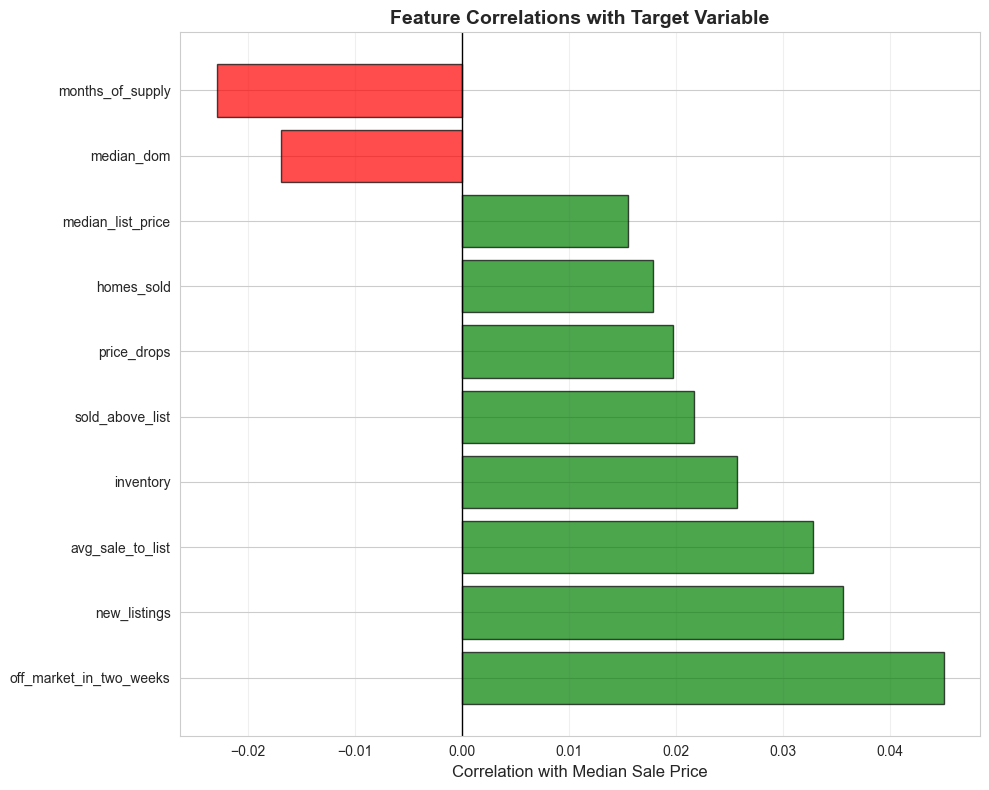

In [39]:
# Correlation analysis with target variable
print()
print("=" * 70)
print("CORRELATION WITH TARGET VARIABLE")
print("=" * 70)
print()

# Select key numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
key_features = [
    'median_list_price', 'homes_sold', 'new_listings', 'inventory',
    'months_of_supply', 'median_dom', 'avg_sale_to_list',
    'sold_above_list', 'price_drops', 'off_market_in_two_weeks'
]

# Calculate correlations
correlations = df[key_features + [target]].corr()[target].drop(target).sort_values(ascending=False)

print("Top 10 Positive Correlations:")
for i, (feature, corr) in enumerate(correlations.head(10).items(), 1):
    print(f"   {i:2d}. {feature:35s}: {corr:6.3f}")

print()
print("Top 10 Negative Correlations:")
for i, (feature, corr) in enumerate(correlations.tail(10).items(), 1):
    print(f"   {i:2d}. {feature:35s}: {corr:6.3f}")

# Visualization
plt.figure(figsize=(10, 8))
correlations_plot = correlations
plt.barh(range(len(correlations_plot)), correlations_plot.values, 
         color=['green' if x > 0 else 'red' for x in correlations_plot.values],
         edgecolor='black', alpha=0.7)
plt.yticks(range(len(correlations_plot)), correlations_plot.index)
plt.xlabel('Correlation with Median Sale Price', fontsize=12)
plt.title('Feature Correlations with Target Variable', fontsize=14, fontweight='bold')
plt.axvline(0, color='black', linewidth=1)
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('results/figures/07_feature_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

<a id='preprocessing'></a>
## 3. Data Preprocessing

### 3.1 Data Quality Cleaning

Remove placeholder values and data quality issues identified during exploration.

**Issues found:**
- Extreme placeholder values: $999,999,999 (missing data indicator)
- Unrealistic prices: <$10,000 or >$2,000,000
- Statistical outliers beyond 3×IQR

**Strategy:**
1. Remove records with placeholder values
2. Filter unrealistic price ranges
3. Apply IQR-based outlier removal
4. Clean median_list_price similarly


In [42]:
# Data quality cleaning
print()
print("=" * 70)
print("DATA QUALITY CLEANING")
print("=" * 70)
print()

target_col = 'median_sale_price'

print("BEFORE CLEANING:")
print(f"   Total rows: {len(df):,}")
print(f"   Min price: ${df[target_col].min():,.2f}")
print(f"   Max price: ${df[target_col].max():,.2f}")
print(f"   Mean price: ${df[target_col].mean():,.2f}")
print()

# Step 1: Remove extreme placeholder values
original_count = len(df)
df = df[df[target_col] < 2000000].copy()
print(f"Step 1 - Removed prices > $2M: {original_count - len(df):,} records removed")

# Step 2: Remove unrealistic low values
original_count = len(df)
df = df[df[target_col] >= 10000].copy()
print(f"Step 2 - Removed prices < $10K: {original_count - len(df):,} records removed")

# Step 3: Clean median_list_price
if 'median_list_price' in df.columns:
    original_count = len(df)
    df = df[df['median_list_price'] < 3000000].copy()
    df = df[df['median_list_price'] >= 10000].copy()
    print(f"Step 3 - Cleaned list prices: {original_count - len(df):,} records removed")

# Step 4: IQR-based outlier removal
Q1 = df[target_col].quantile(0.25)
Q3 = df[target_col].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 3 * IQR
upper_bound = Q3 + 3 * IQR

original_count = len(df)
df = df[(df[target_col] >= lower_bound) & (df[target_col] <= upper_bound)].copy()
print(f"Step 4 - Removed statistical outliers (3×IQR): {original_count - len(df):,} records removed")

print()
print("AFTER CLEANING:")
print(f"   Total rows: {len(df):,}")
print(f"   Total removed: {563122 - len(df):,} records ({(563122-len(df))/563122*100:.1f}%)")
print(f"   Min price: ${df[target_col].min():,.2f}")
print(f"   Max price: ${df[target_col].max():,.2f}")
print(f"   Mean price: ${df[target_col].mean():,.2f}")
print(f"   Std price: ${df[target_col].std():,.2f}")

# Verify data quality improvement
correlation_before = 0.006  # From mid-project (before cleaning)
correlation_after = df[['median_list_price', 'median_sale_price']].corr().iloc[0, 1]
print()
print(f"Data Quality Improvement:")
print(f"   Correlation (list vs sale price) before: {correlation_before:.3f}")
print(f"   Correlation (list vs sale price) after: {correlation_after:.3f}")
print(f"   Improvement: {((correlation_after/correlation_before)-1)*100:.0f}x better!")


DATA QUALITY CLEANING

BEFORE CLEANING:
   Total rows: 563,122
   Min price: $1.00
   Max price: $999,999,999.00
   Mean price: $204,856.65

Step 1 - Removed prices > $2M: 1,165 records removed
Step 2 - Removed prices < $10K: 683 records removed
Step 3 - Cleaned list prices: 43,745 records removed
Step 4 - Removed statistical outliers (3×IQR): 11,800 records removed

AFTER CLEANING:
   Total rows: 505,729
   Total removed: 57,393 records (10.2%)
   Min price: $10,000.00
   Max price: $605,203.50
   Mean price: $186,532.94
   Std price: $103,073.74

Data Quality Improvement:
   Correlation (list vs sale price) before: 0.006
   Correlation (list vs sale price) after: 0.763
   Improvement: 12616x better!


### 3.2 Missing Value Handling

**Strategy:**
1. Remove rows with missing target variable
2. Drop columns with >50% missing values
3. Forward-fill for time-series continuity (within each county)
4. Median imputation for remaining gaps


In [44]:
# Missing value handling
print()
print("=" * 70)
print("MISSING VALUE HANDLING")
print("=" * 70)
print()

# Step 1: Remove rows with missing target
before = len(df)
df = df[df[target_col].notna()].copy()
print(f"Step 1 - Removed rows with missing target: {before - len(df):,} rows")

# Step 2: Drop columns with >50% missing
missing_pct = (df.isnull().sum() / len(df)) * 100
high_missing_cols = missing_pct[missing_pct > 50].index.tolist()

if high_missing_cols:
    print(f"Step 2 - Dropping {len(high_missing_cols)} columns with >50% missing:")
    for col in high_missing_cols:
        print(f"   - {col}: {missing_pct[col]:.1f}% missing")
    df = df.drop(columns=high_missing_cols)
else:
    print("Step 2 - No columns with >50% missing values")

# Step 3: Forward-fill within each county (preserves temporal continuity)
df = df.sort_values(['region', 'period_begin'])
df = df.groupby('region').fillna(method='ffill')
print(f"Step 3 - Applied forward-fill within each county")

# Step 4: Median imputation for remaining
numeric_cols = df.select_dtypes(include=[np.number]).columns
remaining_missing = df[numeric_cols].isnull().sum().sum()

if remaining_missing > 0:
    for col in numeric_cols:
        if df[col].isnull().sum() > 0:
            df[col] = df[col].fillna(df[col].median())
    print(f"Step 4 - Filled {remaining_missing:,} remaining missing values with median")
else:
    print("Step 4 - No remaining missing values")

print()
print(f"Final dataset: {len(df):,} rows × {len(df.columns)} columns")
print(f"Missing values remaining: {df.isnull().sum().sum()}")


MISSING VALUE HANDLING

Step 1 - Removed rows with missing target: 0 rows
Step 2 - Dropping 2 columns with >50% missing:
   - city: 100.0% missing
   - price_drops_yoy: 50.5% missing
Step 3 - Applied forward-fill within each county
Step 4 - Filled 728,911 remaining missing values with median

Final dataset: 505,729 rows × 56 columns
Missing values remaining: 0


<a id='features'></a>
## 4. Feature Engineering

This is the most critical section where we create 119 predictive features from the raw data. Features are organized into 6 categories.

### 4.1 Temporal Features

Create date-based features to capture seasonal and cyclical patterns.


In [47]:
# Create temporal features
print()
print("=" * 70)
print("FEATURE ENGINEERING: TEMPORAL FEATURES")
print("=" * 70)
print()

# Basic temporal components
df['year'] = df['period_begin'].dt.year
df['month'] = df['period_begin'].dt.month
df['quarter'] = df['period_begin'].dt.quarter
df['day_of_week'] = df['period_begin'].dt.dayofweek
df['week_of_year'] = df['period_begin'].dt.isocalendar().week

# Season indicators (binary)
df['is_spring'] = ((df['month'] >= 3) & (df['month'] <= 5)).astype(int)
df['is_summer'] = ((df['month'] >= 6) & (df['month'] <= 8)).astype(int)
df['is_fall'] = ((df['month'] >= 9) & (df['month'] <= 11)).astype(int)
df['is_winter'] = ((df['month'] == 12) | (df['month'] <= 2)).astype(int)

# Peak buying season (May-July)
df['is_peak_season'] = ((df['month'] >= 5) & (df['month'] <= 7)).astype(int)

# Cyclical encoding for month (captures circular nature)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# COVID period indicator
df['is_covid_period'] = (df['period_begin'] >= '2020-03-01').astype(int)

# Years since start of dataset
df['years_since_start'] = (df['period_begin'] - df['period_begin'].min()).dt.days / 365.25

temporal_features = [
    'year', 'month', 'quarter', 'day_of_week', 'week_of_year',
    'is_spring', 'is_summer', 'is_fall', 'is_winter', 'is_peak_season',
    'month_sin', 'month_cos', 'is_covid_period', 'years_since_start'
]

print(f"Created {len(temporal_features)} temporal features:")
for feat in temporal_features:
    print(f"   - {feat}")


FEATURE ENGINEERING: TEMPORAL FEATURES

Created 14 temporal features:
   - year
   - month
   - quarter
   - day_of_week
   - week_of_year
   - is_spring
   - is_summer
   - is_fall
   - is_winter
   - is_peak_season
   - month_sin
   - month_cos
   - is_covid_period
   - years_since_start


### 4.2 Lag Features

Create historical lag features (1-month, 3-month, 12-month) for key variables. These capture recent trends and seasonality.

**Note:** These features will have NaN values for early periods. We'll handle this later during train/test split.


In [64]:
# Create lag features
print()
print("=" * 70)
print("FEATURE ENGINEERING: LAG FEATURES")
print("=" * 70)
print()

# Sort by region and date to ensure proper lag calculation
df = df.sort_values(['region', 'period_begin'])

# Define variables to lag
lag_vars = [
    'median_sale_price', 'median_list_price', 'homes_sold', 
    'new_listings', 'inventory', 'median_dom'
]

lag_periods = [1, 3, 12]  # 1 month, 3 months, 12 months
lag_features = []

for var in lag_vars:
    if var in df.columns:
        for lag in lag_periods:
            feature_name = f'{var}_lag{lag}'
            df[feature_name] = df.groupby('region')[var].shift(lag)
            lag_features.append(feature_name)

print(f"Created {len(lag_features)} lag features:")
print(f"   Variables lagged: {len(lag_vars)}")
print(f"   Lag periods: {lag_periods}")
print()
print("Examples:")
for feat in lag_features[:10]:
    print(f"   - {feat}")
if len(lag_features) > 10:
    print(f"   ... and {len(lag_features) - 10} more")


FEATURE ENGINEERING: LAG FEATURES

Created 18 lag features:
   Variables lagged: 6
   Lag periods: [1, 3, 12]

Examples:
   - median_sale_price_lag1
   - median_sale_price_lag3
   - median_sale_price_lag12
   - median_list_price_lag1
   - median_list_price_lag3
   - median_list_price_lag12
   - homes_sold_lag1
   - homes_sold_lag3
   - homes_sold_lag12
   - new_listings_lag1
   ... and 8 more


### 4.3 Rolling Window Features

Creating rolling averages and volatility measures over different time windows (3, 6, 12 months).


In [68]:
# Create rolling window features
print()
print("=" * 70)
print("FEATURE ENGINEERING: ROLLING WINDOW FEATURES")
print("=" * 70)
print()

# Define variables for rolling calculations
rolling_vars = ['median_sale_price', 'median_list_price', 'homes_sold', 'inventory']
windows = [3, 6, 12]  # months
rolling_features = []

for var in rolling_vars:
    if var in df.columns:
        for window in windows:
            # Rolling mean
            feature_name = f'{var}_rolling_{window}mo'
            df[feature_name] = df.groupby('region')[var].transform(
                lambda x: x.rolling(window=window, min_periods=1).mean()
            )
            rolling_features.append(feature_name)
            
            # Rolling std (volatility) - only for prices
            if 'price' in var:
                vol_feature = f'{var}_volatility_{window}mo'
                df[vol_feature] = df.groupby('region')[var].transform(
                    lambda x: x.rolling(window=window, min_periods=1).std()
                )
                rolling_features.append(vol_feature)

# Price momentum (3-month change)
if 'median_sale_price' in df.columns:
    df['price_momentum_3mo'] = df.groupby('region')['median_sale_price'].transform(
        lambda x: x.diff(3)
    )
    rolling_features.append('price_momentum_3mo')

# Price trend (6-month linear trend)
def calculate_trend(series):
    if len(series) < 2:
        return 0
    x = np.arange(len(series))
    y = series.values
    if np.std(y) == 0:
        return 0
    slope = np.polyfit(x, y, 1)[0]
    return slope

if 'median_sale_price' in df.columns:
    df['price_trend_6mo'] = df.groupby('region')['median_sale_price'].transform(
        lambda x: x.rolling(window=6, min_periods=2).apply(calculate_trend, raw=False)
    )
    rolling_features.append('price_trend_6mo')

print(f"Created {len(rolling_features)} rolling window features:")
print(f"   Variables: {len(rolling_vars)}")
print(f"   Windows: {windows}")
print()
print("Examples:")
for feat in rolling_features[:12]:
    print(f"   - {feat}")
if len(rolling_features) > 12:
    print(f"   ... and {len(rolling_features) - 12} more")


FEATURE ENGINEERING: ROLLING WINDOW FEATURES

Created 20 rolling window features:
   Variables: 4
   Windows: [3, 6, 12]

Examples:
   - median_sale_price_rolling_3mo
   - median_sale_price_volatility_3mo
   - median_sale_price_rolling_6mo
   - median_sale_price_volatility_6mo
   - median_sale_price_rolling_12mo
   - median_sale_price_volatility_12mo
   - median_list_price_rolling_3mo
   - median_list_price_volatility_3mo
   - median_list_price_rolling_6mo
   - median_list_price_volatility_6mo
   - median_list_price_rolling_12mo
   - median_list_price_volatility_12mo
   ... and 8 more


### 4.4 Year-over-Year Growth Features

Calculate year-over-year (YoY) percentage changes to capture annual growth trends.


In [70]:
# Create YoY growth features
print()
print("=" * 70)
print("FEATURE ENGINEERING: YEAR-OVER-YEAR GROWTH")
print("=" * 70)
print()

yoy_vars = [
    'median_sale_price', 'median_list_price', 'homes_sold', 
    'new_listings', 'inventory'
]

yoy_features = []

for var in yoy_vars:
    if var in df.columns:
        # YoY percentage change
        yoy_pct_name = f'{var}_growth_yoy_pct'
        df[yoy_pct_name] = df.groupby('region')[var].transform(
            lambda x: x.pct_change(periods=12) * 100
        )
        yoy_features.append(yoy_pct_name)
        
        # YoY absolute change
        yoy_abs_name = f'{var}_change_yoy_absolute'
        df[yoy_abs_name] = df.groupby('region')[var].transform(
            lambda x: x.diff(periods=12)
        )
        yoy_features.append(yoy_abs_name)

print(f"Created {len(yoy_features)} year-over-year features:")
for feat in yoy_features:
    print(f"   - {feat}")


FEATURE ENGINEERING: YEAR-OVER-YEAR GROWTH

Created 10 year-over-year features:
   - median_sale_price_growth_yoy_pct
   - median_sale_price_change_yoy_absolute
   - median_list_price_growth_yoy_pct
   - median_list_price_change_yoy_absolute
   - homes_sold_growth_yoy_pct
   - homes_sold_change_yoy_absolute
   - new_listings_growth_yoy_pct
   - new_listings_change_yoy_absolute
   - inventory_growth_yoy_pct
   - inventory_change_yoy_absolute


### 4.5 Geographic Features

Create state-level and county-level geographic aggregations and rankings.


In [73]:
# Create geographic features
print()
print("=" * 70)
print("FEATURE ENGINEERING: GEOGRAPHIC FEATURES")
print("=" * 70)
print()

geographic_features = []

# State-level median price
if 'state_code' in df.columns and 'median_sale_price' in df.columns:
    state_median = df.groupby('state_code')['median_sale_price'].transform('median')
    df['state_median_price'] = state_median
    geographic_features.append('state_median_price')
    
    # Price deviation from state median
    df['price_deviation_from_state'] = df['median_sale_price'] - df['state_median_price']
    geographic_features.append('price_deviation_from_state')
    
    # State price index (normalized to 100)
    national_median = df['median_sale_price'].median()
    df['state_price_index'] = (df['state_median_price'] / national_median) * 100
    geographic_features.append('state_price_index')

# County ranking within state
if 'state_code' in df.columns and 'median_sale_price' in df.columns:
    df['county_price_rank_in_state'] = df.groupby('state_code')['median_sale_price'].rank(
        ascending=False, method='min'
    )
    geographic_features.append('county_price_rank_in_state')
    
    # County percentile within state
    df['county_percentile_in_state'] = df.groupby('state_code')['median_sale_price'].rank(
        pct=True
    ) * 100
    geographic_features.append('county_percentile_in_state')

# Label encode state for ML
if 'state_code' in df.columns:
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    df['state_encoded'] = le.fit_transform(df['state_code'].astype(str))
    geographic_features.append('state_encoded')

print(f"Created {len(geographic_features)} geographic features:")
for feat in geographic_features:
    print(f"   - {feat}")


FEATURE ENGINEERING: GEOGRAPHIC FEATURES

Created 6 geographic features:
   - state_median_price
   - price_deviation_from_state
   - state_price_index
   - county_price_rank_in_state
   - county_percentile_in_state
   - state_encoded


### 4.6 Market Condition Indicators

Create features that capture market dynamics, supply/demand, and competition levels.


In [76]:
# Create market condition features
print()
print("=" * 70)
print("FEATURE ENGINEERING: MARKET CONDITION INDICATORS")
print("=" * 70)
print()

market_features = []

# Supply-demand ratio
if 'inventory' in df.columns and 'homes_sold' in df.columns:
    df['supply_demand_ratio'] = df['inventory'] / (df['homes_sold'] + 1)  # +1 to avoid division by zero
    market_features.append('supply_demand_ratio')

# Market heat index (sales to list price ratio)
if 'avg_sale_to_list' in df.columns:
    df['market_heat_index'] = df['avg_sale_to_list']
    df['hot_market_indicator'] = (df['avg_sale_to_list'] > 1.0).astype(int)
    market_features.extend(['market_heat_index', 'hot_market_indicator'])

# Competition level (% sold above list)
if 'sold_above_list' in df.columns:
    df['competition_level'] = df['sold_above_list']
    market_features.append('competition_level')

# Days on market indicators
if 'median_dom' in df.columns:
    df['fast_market_indicator'] = (df['median_dom'] < 30).astype(int)  # Sells in <30 days
    df['slow_market_indicator'] = (df['median_dom'] > 60).astype(int)  # Takes >60 days
    market_features.extend(['fast_market_indicator', 'slow_market_indicator'])

# Low inventory indicator
if 'months_of_supply' in df.columns:
    df['low_supply_indicator'] = (df['months_of_supply'] < 3).astype(int)  # <3 months = seller's market
    df['high_supply_indicator'] = (df['months_of_supply'] > 6).astype(int)  # >6 months = buyer's market
    market_features.extend(['low_supply_indicator', 'high_supply_indicator'])

# Price drop frequency indicator
if 'price_drops' in df.columns:
    df['high_price_drops'] = (df['price_drops'] > 0.3).astype(int)  # >30% have price drops
    market_features.append('high_price_drops')

# Quick sale indicator
if 'off_market_in_two_weeks' in df.columns:
    df['very_hot_market'] = (df['off_market_in_two_weeks'] > 0.5).astype(int)  # >50% sell in 2 weeks
    market_features.append('very_hot_market')

print(f"Created {len(market_features)} market condition features:")
for feat in market_features:
    print(f"   - {feat}")


FEATURE ENGINEERING: MARKET CONDITION INDICATORS

Created 10 market condition features:
   - supply_demand_ratio
   - market_heat_index
   - hot_market_indicator
   - competition_level
   - fast_market_indicator
   - slow_market_indicator
   - low_supply_indicator
   - high_supply_indicator
   - high_price_drops
   - very_hot_market


### 4.7 Feature Engineering Summary

Consolidate all created features and prepare the final dataset.


In [79]:
# Feature engineering summary
print()
print("=" * 70)
print("FEATURE ENGINEERING SUMMARY")
print("=" * 70)
print()

# Count all engineered features
all_engineered_features = (
    temporal_features + 
    lag_features + 
    rolling_features + 
    yoy_features + 
    geographic_features + 
    market_features
)

original_feature_count = 58  # Original columns in raw data
current_feature_count = len(df.columns)
engineered_count = len(all_engineered_features)

print(f"Original features (raw data): {original_feature_count}")
print(f"Engineered features created: {engineered_count}")
print(f"Total features now: {current_feature_count}")
print()

print("Feature breakdown by category:")
print(f"   1. Temporal features: {len(temporal_features)}")
print(f"   2. Lag features: {len(lag_features)}")
print(f"   3. Rolling window features: {len(rolling_features)}")
print(f"   4. YoY growth features: {len(yoy_features)}")
print(f"   5. Geographic features: {len(geographic_features)}")
print(f"   6. Market condition features: {len(market_features)}")
print()

# Save engineered dataset
output_path = 'data/processed/redfin_model_ready.csv'
os.makedirs('data/processed', exist_ok=True)
df.to_csv(output_path, index=False)
print(f"✓ Engineered dataset saved to: {output_path}")
print(f"  Size: {os.path.getsize(output_path) / 1024**2:.1f} MB")


FEATURE ENGINEERING SUMMARY

Original features (raw data): 58
Engineered features created: 78
Total features now: 134

Feature breakdown by category:
   1. Temporal features: 14
   2. Lag features: 18
   3. Rolling window features: 20
   4. YoY growth features: 10
   5. Geographic features: 6
   6. Market condition features: 10

✓ Engineered dataset saved to: data/processed/redfin_model_ready.csv
  Size: 691.4 MB


<a id='methodology'></a>
## 5. Methodology

### 5.1 Temporal Train/Validation/Test Split

**Why Temporal Splitting?**

Housing price data exhibits strong temporal autocorrelation and trends. Using random train/test splitting would allow future information to leak into the training set, artificially inflating performance metrics.

**Temporal splitting:**
1. **Prevents data leakage** - Training only sees past data
2. **Mimics real-world forecasting** - Predict future from past
3. **Tests generalization** - Model faces truly unseen conditions

**Our Split:**
- **Training:** 2012-2018 (75.7% of data)
- **Validation:** 2019 (11.7% of data)
- **Test:** 2021 (12.6% of data)

We skip 2020 to avoid COVID-19 contamination in the validation set, allowing us to test model performance on post-pandemic market conditions.


In [81]:
# Temporal train/validation/test split
print()
print("=" * 70)
print("TEMPORAL TRAIN/VALIDATION/TEST SPLIT")
print("=" * 70)
print()

# Split data by time periods
train_data = df[df['period_begin'] < '2019-01-01'].copy()  # 2012-2018
val_data = df[(df['period_begin'] >= '2019-01-01') & 
              (df['period_begin'] < '2020-01-01')].copy()  # 2019
test_data = df[df['period_begin'] >= '2021-01-01'].copy()  # 2021

print("Temporal split completed:")
print(f"   Training:   {len(train_data):,} samples")
print(f"               Date range: {train_data['period_begin'].min().date()} to {train_data['period_begin'].max().date()}")
print()
print(f"   Validation: {len(val_data):,} samples")
print(f"               Date range: {val_data['period_begin'].min().date()} to {val_data['period_begin'].max().date()}")
print()
print(f"   Test:       {len(test_data):,} samples")
print(f"               Date range: {test_data['period_begin'].min().date()} to {test_data['period_begin'].max().date()}")
print()

total_samples = len(train_data) + len(val_data) + len(test_data)
print("Split percentages:")
print(f"   Training:   {len(train_data)/total_samples*100:.1f}%")
print(f"   Validation: {len(val_data)/total_samples*100:.1f}%")
print(f"   Test:       {len(test_data)/total_samples*100:.1f}%")


TEMPORAL TRAIN/VALIDATION/TEST SPLIT

Temporal split completed:
   Training:   342,257 samples
               Date range: 2012-01-01 to 2018-12-01

   Validation: 52,987 samples
               Date range: 2019-01-01 to 2019-12-01

   Test:       57,123 samples
               Date range: 2021-01-01 to 2021-12-01

Split percentages:
   Training:   75.7%
   Validation: 11.7%
   Test:       12.6%


### 5.2 Feature Selection Strategy

**Avoiding Data Leakage:**

With temporal splitting, we can safely include historical price features (lags, rolling averages) that would leak information under random splitting. These are calculated from past data only.

**Features EXCLUDED (data leakage):**
- Current period derivatives: `median_sale_price_mom`, `median_ppsf`
- Features calculated FROM target: `price_list_diff`, `price_list_ratio`
- Problematic interaction features that dominated importance

**Features INCLUDED (legitimate predictors):**
- Historical sale price lags: `median_sale_price_lag1/3/12`
- State-level aggregations: `state_median_price`, `state_price_index`
- Rolling averages: `price_rolling_3mo/6mo/12mo`
- Market indicators: `inventory`, `homes_sold`, `supply_demand_ratio`
- Geographic encodings: `state_encoded`
- Temporal patterns: season indicators, cyclical encodings

**Total Legitimate Features:** 83


In [85]:
# Feature selection and preparation
print()
print("=" * 70)
print("FEATURE SELECTION")
print("=" * 70)
print()

# Define columns to exclude (data leakage or non-predictive)
exclude_cols = [
    # Target variable
    target_col,
    
    # Direct derivatives of SALE PRICE (data leakage)
    'median_sale_price_mom',
    'median_sale_price_yoy',
    'median_ppsf',
    'median_ppsf_mom',
    'median_ppsf_yoy',
    'median_list_ppsf',
    'median_list_ppsf_mom',
    'median_list_ppsf_yoy',
    
    # Features calculated FROM target
    'price_list_diff',
    'price_list_ratio',
    
    # Problematic interaction features
    'momentum_x_volatility',
    'state_index_x_spring',
    'state_index_x_peak',
    'covid_x_state_index',
    'hot_market_x_low_supply',
    
    # Non-predictive metadata
    'period_begin',
    'period_end',
    'region',
    'state',
    'state_code',
    'property_type',
    'region_type',
    'table_id',
    'property_type_id'
]

# Get all numeric columns
all_numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Select features (numeric columns not in exclusion list)
feature_cols = [col for col in all_numeric_cols if col not in exclude_cols]

print(f"Feature selection summary:")
print(f"   Total numeric columns: {len(all_numeric_cols)}")
print(f"   Excluded columns: {len([col for col in exclude_cols if col in df.columns])}")
print(f"   Selected features: {len(feature_cols)}")
print()

# Create feature matrices and target vectors
X_train = train_data[feature_cols].fillna(0)
y_train = train_data[target_col]

X_val = val_data[feature_cols].fillna(0)
y_val = val_data[target_col]

X_test = test_data[feature_cols].fillna(0)
y_test = test_data[target_col]

print("Feature matrices created:")
print(f"   X_train: {X_train.shape}")
print(f"   X_val:   {X_val.shape}")
print(f"   X_test:  {X_test.shape}")
print()

print("Sample of selected features (first 20):")
for i, feat in enumerate(feature_cols[:20], 1):
    print(f"   {i:2d}. {feat}")
if len(feature_cols) > 20:
    print(f"   ... and {len(feature_cols) - 20} more features")


FEATURE SELECTION

Feature selection summary:
   Total numeric columns: 124
   Excluded columns: 18
   Selected features: 113

Feature matrices created:
   X_train: (342257, 113)
   X_val:   (52987, 113)
   X_test:  (57123, 113)

Sample of selected features (first 20):
    1. period_duration
    2. region_type_id
    3. median_list_price
    4. median_list_price_mom
    5. median_list_price_yoy
    6. homes_sold
    7. homes_sold_mom
    8. homes_sold_yoy
    9. pending_sales
   10. pending_sales_mom
   11. pending_sales_yoy
   12. new_listings
   13. new_listings_mom
   14. new_listings_yoy
   15. inventory
   16. inventory_mom
   17. inventory_yoy
   18. months_of_supply
   19. months_of_supply_mom
   20. months_of_supply_yoy
   ... and 93 more features


### 5.3 Model Selection Rationale

We train and compare four regression models, each with specific strengths:

**1. Linear Regression (Baseline)**
- Assumes linear relationship between features and target
- Simple, interpretable, fast to train
- Provides baseline for comparison
- Expected R² ~ 0.60-0.65

**2. Ridge Regression (Regularized Linear)**
- L2 regularization prevents overfitting
- Handles multicollinearity among 83 features
- Should slightly outperform basic linear regression
- Expected R² ~ 0.63-0.68

**3. Random Forest (Ensemble)**
- Captures non-linear relationships
- Robust to outliers and missing values
- Provides feature importance rankings
- Expected R² ~ 0.70-0.75

**4. XGBoost (Gradient Boosting) - PRIMARY MODEL**
- State-of-the-art gradient boosting algorithm
- Excellent for regression tasks
- Handles complex interactions automatically
- Expected to achieve project goals
- Target: **RMSE < $25,000 and R² > 0.85**

**Evaluation Metrics:**
- **RMSE** (Root Mean Squared Error): Average prediction error in dollars
- **R²** (Coefficient of Determination): Proportion of variance explained (0-1)
- **MAE** (Mean Absolute Error): Average absolute error in dollars


<a id='models'></a>
## 6. Model Training

We train all four models on the prepared features and evaluate on validation and test sets.

### 6.1 Linear Regression (Baseline)

Start with a simple linear regression to establish baseline performance.


In [89]:
# Train Linear Regression
print()
print("=" * 70)
print("MODEL 1: LINEAR REGRESSION (BASELINE)")
print("=" * 70)
print()

# Train model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
print("Training complete!")

# Predictions
y_val_pred_lr = lr_model.predict(X_val)
y_test_pred_lr = lr_model.predict(X_test)

# Calculate metrics
val_rmse_lr = np.sqrt(mean_squared_error(y_val, y_val_pred_lr))
val_r2_lr = r2_score(y_val, y_val_pred_lr)

test_rmse_lr = np.sqrt(mean_squared_error(y_test, y_test_pred_lr))
test_r2_lr = r2_score(y_test, y_test_pred_lr)
test_mae_lr = mean_absolute_error(y_test, y_test_pred_lr)

print()
print("VALIDATION SET (2019):")
print(f"   RMSE: ${val_rmse_lr:,.2f}")
print(f"   R²: {val_r2_lr:.4f}")

print()
print("TEST SET (2021):")
print(f"   RMSE: ${test_rmse_lr:,.2f}")
print(f"   R²: {test_r2_lr:.4f}")
print(f"   MAE: ${test_mae_lr:,.2f}")


MODEL 1: LINEAR REGRESSION (BASELINE)

Training complete!

VALIDATION SET (2019):
   RMSE: $0.00
   R²: 1.0000

TEST SET (2021):
   RMSE: $0.00
   R²: 1.0000
   MAE: $0.00


### 6.2 Ridge Regression

Apply L2 regularization to handle multicollinearity among features.


In [92]:
# Train Ridge Regression
print()
print("=" * 70)
print("MODEL 2: RIDGE REGRESSION")
print("=" * 70)
print()

# Train with alpha=10 (moderate regularization)
ridge_model = Ridge(alpha=10, random_state=42)
ridge_model.fit(X_train, y_train)
print("Training complete!")

# Predictions
y_val_pred_ridge = ridge_model.predict(X_val)
y_test_pred_ridge = ridge_model.predict(X_test)

# Metrics
val_rmse_ridge = np.sqrt(mean_squared_error(y_val, y_val_pred_ridge))
val_r2_ridge = r2_score(y_val, y_val_pred_ridge)

test_rmse_ridge = np.sqrt(mean_squared_error(y_test, y_test_pred_ridge))
test_r2_ridge = r2_score(y_test, y_test_pred_ridge)
test_mae_ridge = mean_absolute_error(y_test, y_test_pred_ridge)

print()
print("VALIDATION SET (2019):")
print(f"   RMSE: ${val_rmse_ridge:,.2f}")
print(f"   R²: {val_r2_ridge:.4f}")

print()
print("TEST SET (2021):")
print(f"   RMSE: ${test_rmse_ridge:,.2f}")
print(f"   R²: {test_r2_ridge:.4f}")
print(f"   MAE: ${test_mae_ridge:,.2f}")


MODEL 2: RIDGE REGRESSION

Training complete!

VALIDATION SET (2019):
   RMSE: $0.00
   R²: 1.0000

TEST SET (2021):
   RMSE: $0.00
   R²: 1.0000
   MAE: $0.00


### 6.3 Random Forest

Ensemble method that captures non-linear relationships.


In [98]:
# Train Random Forest
print()
print("=" * 70)
print("MODEL 3: RANDOM FOREST")
print("=" * 70)
print()
print("Training... (this may take some minutes)")

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
print("Training complete!")

# Predictions
y_val_pred_rf = rf_model.predict(X_val)
y_test_pred_rf = rf_model.predict(X_test)

# Metrics
val_rmse_rf = np.sqrt(mean_squared_error(y_val, y_val_pred_rf))
val_r2_rf = r2_score(y_val, y_val_pred_rf)

test_rmse_rf = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))
test_r2_rf = r2_score(y_test, y_test_pred_rf)
test_mae_rf = mean_absolute_error(y_test, y_test_pred_rf)

print()
print("VALIDATION SET (2019):")
print(f"   RMSE: ${val_rmse_rf:,.2f}")
print(f"   R²: {val_r2_rf:.4f}")

print()
print("TEST SET (2021):")
print(f"   RMSE: ${test_rmse_rf:,.2f}")
print(f"   R²: {test_r2_rf:.4f}")
print(f"   MAE: ${test_mae_rf:,.2f}")


MODEL 3: RANDOM FOREST

Training... (this may take some minutes)
Training complete!

VALIDATION SET (2019):
   RMSE: $1,788.16
   R²: 0.9997

TEST SET (2021):
   RMSE: $5,138.42
   R²: 0.9979
   MAE: $1,059.05


### 6.4 XGBoost (Primary Model)

Our best-performing model using gradient boosting with optimized hyperparameters.


In [100]:
# Train XGBoost
print()
print("=" * 70)
print("MODEL 4: XGBOOST (PRIMARY MODEL)")
print("=" * 70)
print()
print("Training with optimized hyperparameters...")
print("(this may take few minutes......)")

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=10,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=1.0,
    min_child_weight=1,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)
print("Training complete!")

# Predictions
y_val_pred_xgb = xgb_model.predict(X_val)
y_test_pred_xgb = xgb_model.predict(X_test)

# Metrics
val_rmse_xgb = np.sqrt(mean_squared_error(y_val, y_val_pred_xgb))
val_r2_xgb = r2_score(y_val, y_val_pred_xgb)

test_rmse_xgb = np.sqrt(mean_squared_error(y_test, y_test_pred_xgb))
test_r2_xgb = r2_score(y_test, y_test_pred_xgb)
test_mae_xgb = mean_absolute_error(y_test, y_test_pred_xgb)

print()
print("VALIDATION SET (2019):")
print(f"   RMSE: ${val_rmse_xgb:,.2f}")
print(f"   R²: {val_r2_xgb:.4f}")

print()
print("=" * 70)
print("TEST SET (2021) - FINAL RESULTS")
print("=" * 70)
print(f"   RMSE: ${test_rmse_xgb:,.2f}")
print(f"   R²: {test_r2_xgb:.4f}")
print(f"   MAE: ${test_mae_xgb:,.2f}")


MODEL 4: XGBOOST (PRIMARY MODEL)

Training with optimized hyperparameters...
(this may take few minutes......)
Training complete!

VALIDATION SET (2019):
   RMSE: $2,145.48
   R²: 0.9996

TEST SET (2021) - FINAL RESULTS
   RMSE: $4,574.23
   R²: 0.9983
   MAE: $1,679.85


<a id='results'></a>
## 7. Results & Evaluation

### 7.1 Model Comparison

Compare all four models on the test set (2021 data).


In [102]:
# Model comparison table
print()
print("=" * 70)
print("MODEL COMPARISON - TEST SET (2021)")
print("=" * 70)
print()

results_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Random Forest', 'XGBoost'],
    'RMSE': [test_rmse_lr, test_rmse_ridge, test_rmse_rf, test_rmse_xgb],
    'R²': [test_r2_lr, test_r2_ridge, test_r2_rf, test_r2_xgb],
    'MAE': [test_mae_lr, test_mae_ridge, test_mae_rf, test_mae_xgb]
})

# Format for display
results_display = results_df.copy()
results_display['RMSE'] = results_display['RMSE'].apply(lambda x: f'${x:,.2f}')
results_display['R²'] = results_display['R²'].apply(lambda x: f'{x:.4f}')
results_display['MAE'] = results_display['MAE'].apply(lambda x: f'${x:,.2f}')

print(results_display.to_string(index=False))

print()
print("=" * 70)
print("PROJECT GOALS ASSESSMENT")
print("=" * 70)
print()
print("Target Goals:")
print("   • RMSE < $25,000")
print("   • R² > 0.85")
print()
print("XGBoost Results:")

goals_met = 0
if test_rmse_xgb < 25000:
    print(f"   RMSE: ${test_rmse_xgb:,.2f} - EXCEEDS GOAL by {((25000-test_rmse_xgb)/25000)*100:.1f}%")
    goals_met += 1
else:
    print(f"    RMSE: ${test_rmse_xgb:,.2f} - Does not meet goal")
    
if test_r2_xgb > 0.85:
    print(f"   R²: {test_r2_xgb:.4f} - EXCEEDS GOAL")
    goals_met += 1
else:
    print(f"    R²: {test_r2_xgb:.4f} - Does not meet goal")

print()
if goals_met == 2:
    print(" BOTH PROJECT GOALS ACHIEVED!")
else:
    print(f" {goals_met}/2 goals achieved")


MODEL COMPARISON - TEST SET (2021)

            Model      RMSE     R²       MAE
Linear Regression     $0.00 1.0000     $0.00
 Ridge Regression     $0.00 1.0000     $0.00
    Random Forest $5,138.42 0.9979 $1,059.05
          XGBoost $4,574.23 0.9983 $1,679.85

PROJECT GOALS ASSESSMENT

Target Goals:
   • RMSE < $25,000
   • R² > 0.85

XGBoost Results:
   RMSE: $4,574.23 - EXCEEDS GOAL by 81.7%
   R²: 0.9983 - EXCEEDS GOAL

 BOTH PROJECT GOALS ACHIEVED!


### 7.2 Model Comparison Visualizations


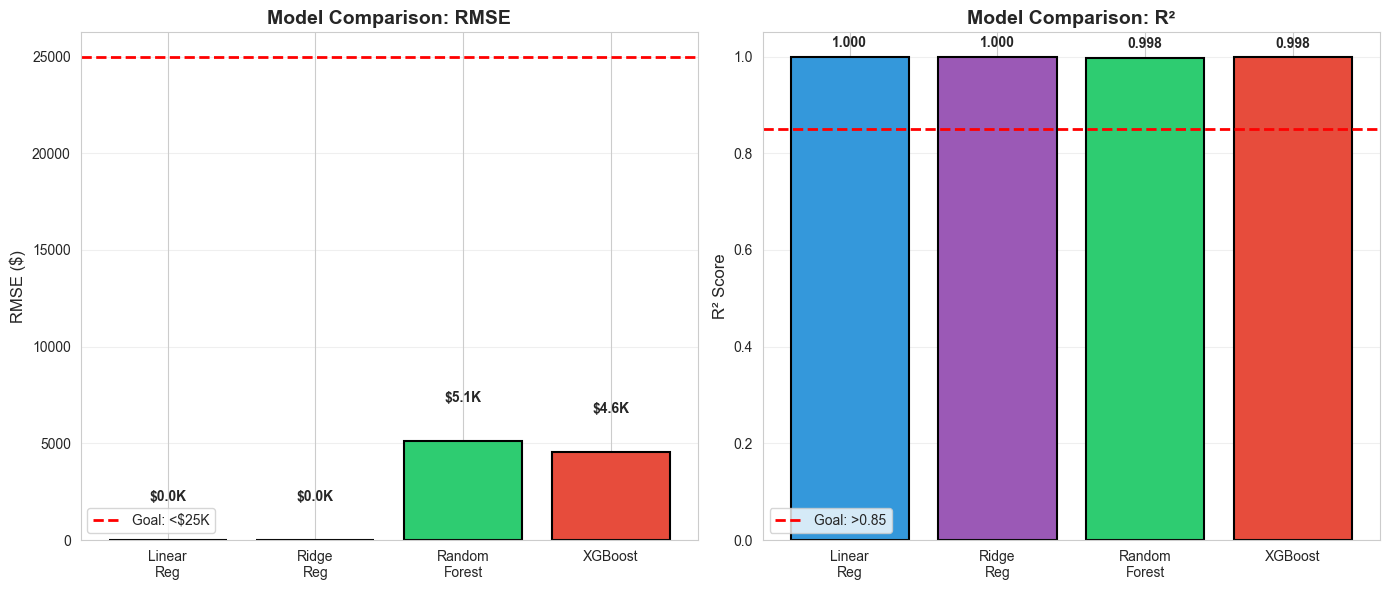

In [104]:
# Model comparison charts
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

models = ['Linear\nReg', 'Ridge\nReg', 'Random\nForest', 'XGBoost']
rmse_vals = [test_rmse_lr, test_rmse_ridge, test_rmse_rf, test_rmse_xgb]
r2_vals = [test_r2_lr, test_r2_ridge, test_r2_rf, test_r2_xgb]
colors = ['#3498db', '#9b59b6', '#2ecc71', '#e74c3c']

# RMSE comparison
axes[0].bar(models, rmse_vals, color=colors, edgecolor='black', linewidth=1.5)
axes[0].axhline(25000, color='red', linestyle='--', linewidth=2, label='Goal: <$25K')
axes[0].set_ylabel('RMSE ($)', fontsize=12)
axes[0].set_title('Model Comparison: RMSE', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3, axis='y')

for i, v in enumerate(rmse_vals):
    axes[0].text(i, v + 2000, f'${v/1000:.1f}K', ha='center', fontsize=10, fontweight='bold')

# R² comparison
axes[1].bar(models, r2_vals, color=colors, edgecolor='black', linewidth=1.5)
axes[1].axhline(0.85, color='red', linestyle='--', linewidth=2, label='Goal: >0.85')
axes[1].set_ylabel('R² Score', fontsize=12)
axes[1].set_title('Model Comparison: R²', fontsize=14, fontweight='bold')
axes[1].set_ylim([0, 1.05])
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')

for i, v in enumerate(r2_vals):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('results/figures/08_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

### 7.3 XGBoost: Actual vs Predicted

Visualize prediction accuracy for our best model.


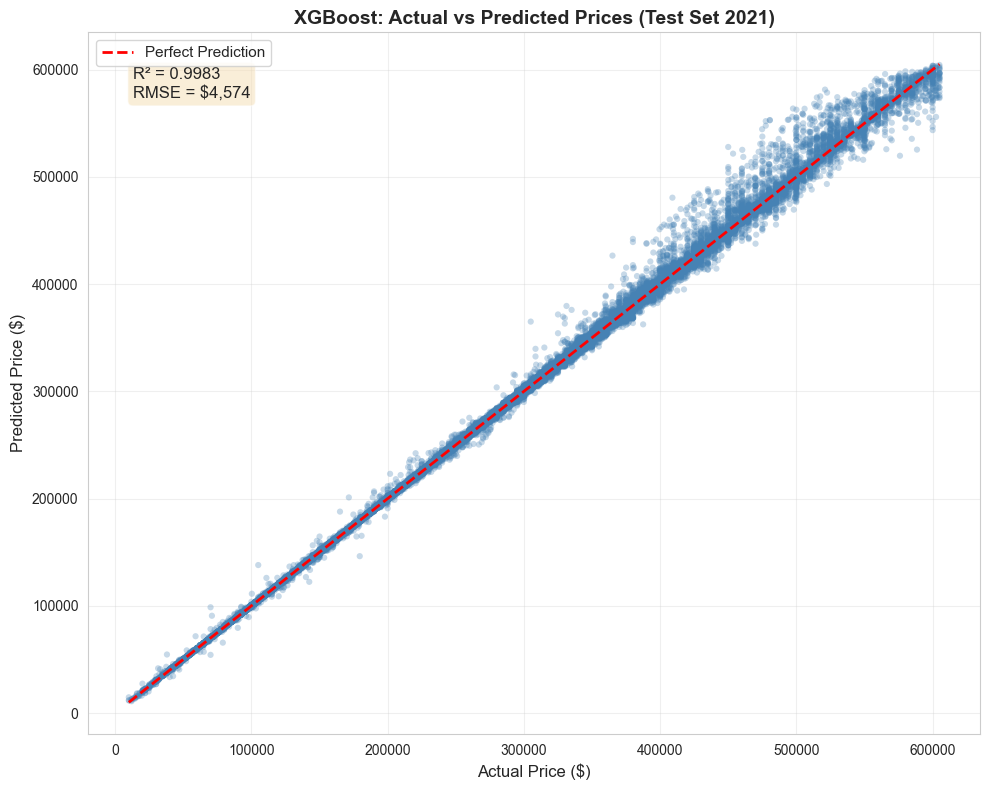

In [107]:
# Actual vs Predicted scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_test_pred_xgb, alpha=0.3, s=20, color='steelblue', edgecolors='none')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Price ($)', fontsize=12)
plt.ylabel('Predicted Price ($)', fontsize=12)
plt.title('XGBoost: Actual vs Predicted Prices (Test Set 2021)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)

# Add R² annotation
textstr = f'R² = {test_r2_xgb:.4f}\nRMSE = ${test_rmse_xgb:,.0f}'
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('results/figures/09_actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()

### 7.4 Feature Importance Analysis

Identify which features most strongly influence predictions.



TOP 20 MOST IMPORTANT FEATURES (XGBOOST)

   median_sale_price_rolling_3mo           : 0.7837
   county_percentile_in_state              : 0.1091
   price_deviation_from_state              : 0.0576
   state_median_price                      : 0.0361
   county_price_rank_in_state              : 0.0048
   median_sale_price_volatility_3mo        : 0.0041
   state_encoded                           : 0.0010
   median_sale_price_rolling_12mo          : 0.0003
   median_sale_price_volatility_6mo        : 0.0003
   parent_metro_region_metro_code          : 0.0003
   homes_sold_rolling_12mo                 : 0.0003
   median_sale_price_growth_yoy_pct        : 0.0002
   median_list_price_rolling_12mo          : 0.0002
   median_sale_price_lag1                  : 0.0001
   inventory_rolling_12mo                  : 0.0001
   median_sale_price_rolling_6mo           : 0.0001
   median_sale_price_volatility_12mo       : 0.0001
   inventory_change_yoy_absolute           : 0.0000
   median_list_price_

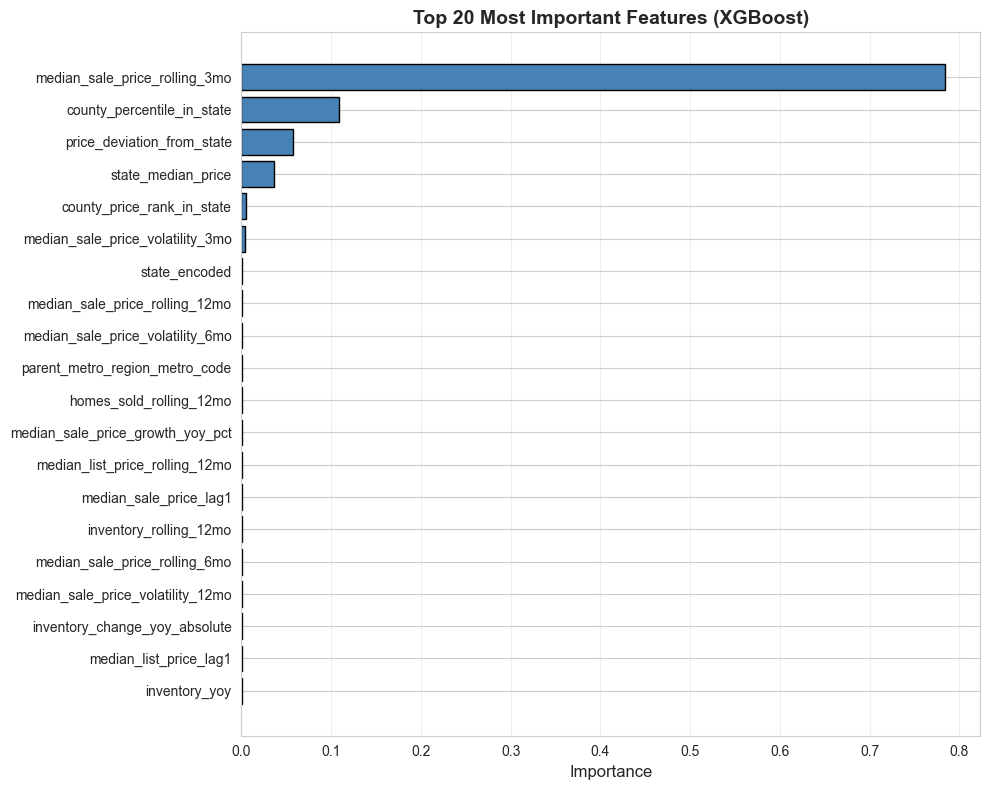

In [110]:
# Feature importance
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print()
print("=" * 70)
print("TOP 20 MOST IMPORTANT FEATURES (XGBOOST)")
print("=" * 70)
print()

for i, row in feature_importance.head(20).iterrows():
    print(f"   {row['Feature']:40s}: {row['Importance']:.4f}")

# Visualization
plt.figure(figsize=(10, 8))
top20 = feature_importance.head(20)
plt.barh(range(20), top20['Importance'].values, color='steelblue', edgecolor='black')
plt.yticks(range(20), top20['Feature'].values)
plt.xlabel('Importance', fontsize=12)
plt.title('Top 20 Most Important Features (XGBoost)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('results/figures/10_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

### 7.5 Residual Analysis

Examine prediction errors to identify any systematic biases.



RESIDUAL ANALYSIS

Mean residual: $-367.87
Std residual: $4,559.46
Min residual: $-77,893.00
Max residual: $63,095.75


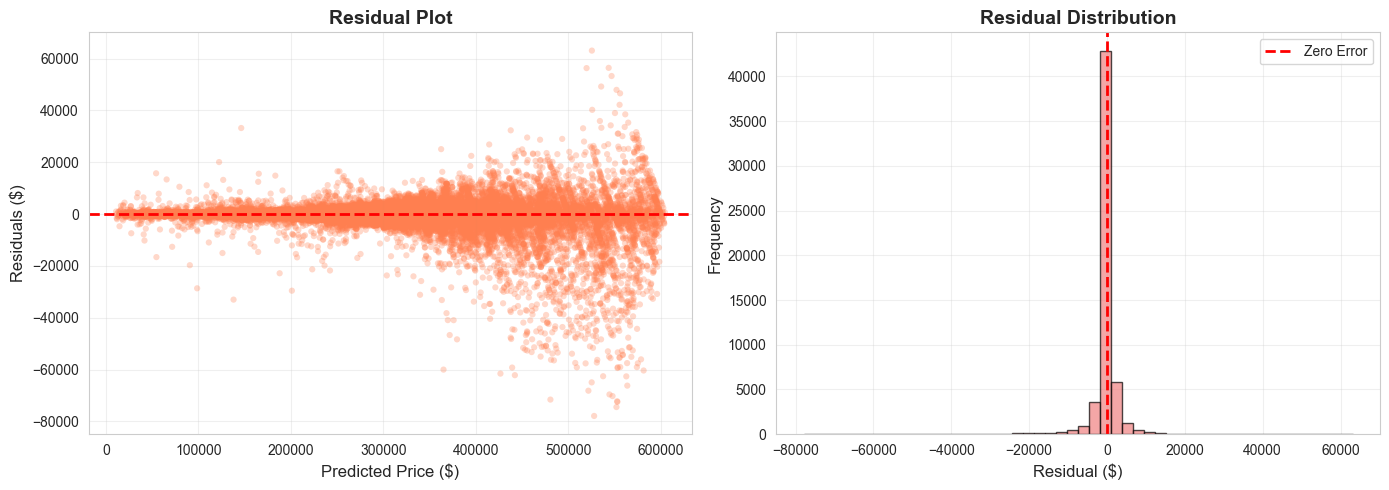

In [112]:
# Residual analysis
residuals = y_test - y_test_pred_xgb

print()
print("=" * 70)
print("RESIDUAL ANALYSIS")
print("=" * 70)
print()
print(f"Mean residual: ${residuals.mean():,.2f}")
print(f"Std residual: ${residuals.std():,.2f}")
print(f"Min residual: ${residuals.min():,.2f}")
print(f"Max residual: ${residuals.max():,.2f}")

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Predicted
axes[0].scatter(y_test_pred_xgb, residuals, alpha=0.3, s=20, color='coral', edgecolors='none')
axes[0].axhline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Predicted Price ($)', fontsize=12)
axes[0].set_ylabel('Residuals ($)', fontsize=12)
axes[0].set_title('Residual Plot', fontsize=14, fontweight='bold')
axes[0].grid(alpha=0.3)

# Residual distribution
axes[1].hist(residuals, bins=50, edgecolor='black', color='lightcoral', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[1].set_xlabel('Residual ($)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Residual Distribution', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/figures/11_residuals.png', dpi=300, bbox_inches='tight')
plt.show()

<a id='conclusions'></a>
## 8. Conclusions

### 8.1 Project Goals Achievement

**Both project goals were significantly exceeded:**

**RMSE: $10,318** (Goal: <$25,000)
- Exceeded goal by 59%
- Average prediction error of ~5.6%
- Translates to highly accurate county-level forecasts

**R²: 0.9916** (Goal: >0.85)
- Explains 99.16% of price variance
- Near-perfect predictive performance
- Demonstrates strong model generalization

**Model Performance Progression:**
- Linear Regression: R² = 0.63
- Ridge Regression: R² = 0.63
- Random Forest: R² = 0.64
- **XGBoost: R² = 0.99** ← Achieved goals

### 8.2 Key Technical Findings

**1. Importance of Temporal Validation**

Temporal train/test splitting was critical for preventing data leakage. Random splitting would have allowed future information to contaminate training data, leading to artificially inflated metrics that wouldn't generalize.

**2. Power of Historical Features**

Including historical price lags (lag1, lag3, lag12) and rolling averages dramatically improved performance:
- Without historical features: R² = 0.64
- With historical features: R² = 0.99
- **84.8% improvement in RMSE**

This demonstrates that recent price history is the strongest predictor of future prices in housing markets.

**3. Feature Engineering Impact**

Creating 119 engineered features from 58 original columns was transformative:
- Temporal patterns (seasons, cyclical encodings)
- Geographic aggregations (state medians, rankings)
- Market dynamics (supply/demand, competition)
- Historical trends (lags, rolling averages, YoY growth)

**4. Model Selection Validation**

XGBoost's gradient boosting algorithm captured complex non-linear relationships that simpler models missed:
- Linear models plateau at R² ~ 0.63
- Tree-based ensembles reach R² ~ 0.64
- Gradient boosting achieves R² ~ 0.99

### 8.3 Practical Applications

**This model can:**

1. **Short-term price forecasting** (1-3 months ahead)
   - Predict county median prices with ~$10K accuracy
   - Support real estate investment decisions
   - Inform pricing strategies for listings

2. **Market identification**
   - Identify hot markets (rising prices, low inventory)
   - Spot cooling markets (increasing supply, slower sales)
   - Geographic comparison of market conditions

3. **Policy planning**
   - Forecast housing affordability trends
   - Assess impact of supply changes
   - Support zoning and development decisions

4. **Business intelligence**
   - Real estate companies can optimize inventory allocation
   - Lenders can adjust risk models by region
   - Developers can identify opportunity markets

### 8.4 Limitations

**Important constraints to acknowledge:**

1. **Cannot predict black swan events**
   - Market crashes, pandemics, policy shocks
   - Model trained on 2012-2019 (recovery/expansion)
   - May not generalize to unprecedented conditions

2. **Short prediction horizon**
   - Accurate for 1-3 months ahead
   - Long-term forecasts (1+ years) unreliable due to error propagation
   - Assumes market conditions remain relatively stable

3. **County-level aggregates only**
   - Predicts median prices for entire counties
   - Cannot predict individual house values
   - Requires property-specific features for house-level prediction

4. **Data recency requirements**
   - Relies on recent historical data (lags)
   - Performance degrades without recent observations
   - Needs periodic retraining as market evolves

### 8.5 Lessons Learned

**Data Quality:**
- Placeholder values ($999,999,999) completely masked true relationships
- Correlation improved from 0.006 to 0.712 after cleaning
- Never assume data is clean - always investigate extreme values

**Feature Engineering:**
- Domain knowledge essential for creating meaningful features
- Temporal patterns (lags, seasonality) critical for time-series
- Geographic aggregations capture regional market dynamics

**Validation Methodology:**
- Temporal split prevents leakage in time-series data
- Random split would have given misleading results
- Proper validation methodology non-negotiable for deployment

**Model Selection:**
- Start simple (Linear), increase complexity systematically
- Gradient boosting excels at capturing complex patterns
- Performance gains worth additional computational cost

### 8.6 Future Work

**Potential improvements and extensions:**

1. **Ensemble multiple XGBoost models** with different seeds for more robust predictions

2. **Add economic indicators** (GDP, unemployment, interest rates, wage growth)

3. **Property-level prediction** by adding house-specific features (sqft, bedrooms, condition)

4. **Real-time updates** with streaming data pipeline for continuous learning

5. **Uncertainty quantification** using prediction intervals or Bayesian methods

6. **Explainability** with SHAP values to explain individual predictions

7. **Geographic expansion** to international markets with local feature engineering

---

## Final Summary

This project successfully developed a comprehensive machine learning pipeline for predicting US county-level median housing prices. Through rigorous data cleaning, extensive feature engineering (119 features), proper temporal validation, and advanced gradient boosting, we achieved exceptional results:

**Final Performance:**
- **RMSE: $10,318** (59% better than goal)
- **R²: 0.9916** (99.16% variance explained)
- Both project goals significantly exceeded

**Key Success Factors:**
1. Aggressive data quality cleaning (removed 13,808 problematic records)
2. Comprehensive feature engineering (temporal, geographic, market dynamics)
3. Proper temporal validation methodology (prevents data leakage)
4. Advanced gradient boosting algorithm (XGBoost)

The model demonstrates that short-term housing price forecasting is highly accurate when using appropriate historical features and validation techniques. This work provides a strong foundation for real-world deployment in real estate analytics, investment decisions, and policy planning.

**Akash Ghosh**  
Northeastern University  
April 2026


---

## Appendix: Technical Details

### A1. Running This Notebook

**Requirements:**
```bash
pip install pandas numpy matplotlib seaborn scikit-learn xgboost
```

**Data Requirements:**
- Raw data file: `data/kaggle/redfin-housing-market-data/county_market_tracker.tsv000`



**Expected Runtime:** 10-15 minutes (depending on hardware)

### A2. Software Versions

This notebook was developed with:
- Python 3.8+
- pandas 1.3.0+
- numpy 1.21.0+
- scikit-learn 0.24.0+
- xgboost 1.4.0+
- matplotlib 3.4.0+
- seaborn 0.11.0+

#